# Esame Laboratorio di Programmazione II - 22/07/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e rinominate il file che consegnate come `matricola.ipynb` (la matricola è SMnumeri o ECnumeri).

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domande e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB: Potete usare anche più di una cella python per domanda e se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza etichette sugli assi o illeggibili sarà valutato meno bene di uno con etichette chiare.

Cercate di commmentare il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Esercizio 1

Crea un vettore NumPy con le seguenti spese annuali per l’auto (in euro) sostenute da 7 persone:
3200, 2750, 4100, 3600, 2950, 5100, 4400

1. Calcola la spesa totale complessiva sostenuta dal gruppo.

2. Le persone con spese minori di 3000 € ottengono una detrazione fiscale del 15%. Applica la modifica al vettore.

3. Quanto ha risparmiato il gruppo dopo la detrazione fiscale?


In [2]:
auto = np.array([3200, 2750, 4100, 3600, 2950, 5100, 4400])
print(f"Auto: {auto}\n")
spesa = auto.sum()
auto = np.where(auto<3000, auto*0.85, auto)
risparmio = spesa - auto.sum()
print(f"Spesa: {spesa}\nAuto con detrazione: {auto}\nRisaprmio: {risparmio}")

Auto: [3200 2750 4100 3600 2950 5100 4400]

Spesa: 26100
Auto con detrazione: [3200.  2337.5 4100.  3600.  2507.5 5100.  4400. ]
Risaprmio: 855.0


## Esercizio 2
1. Scrivi una funzione che simula il lancio di un dado per N volte e restituisce un array con il numero di volte che è uscita ciascuna faccia (da 1 a 6).
2. Calcolare la frequenza % con la dimensione del campione (numero di lanci) 100 volte da 10 a 5000.  Ottieni così 100 array di frequenze.
3. Fai il plot dell’andamento della frequenza media delle facce 1, 3 e 6 in funzione della dimensione del campione.



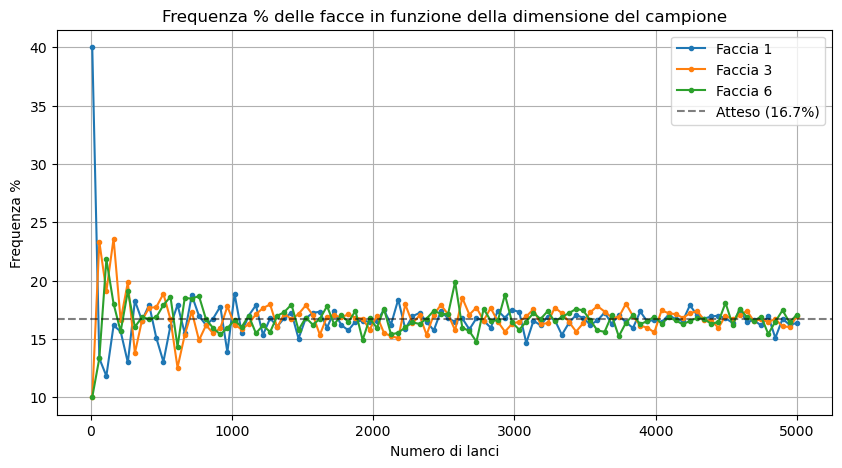

In [4]:
def lancio(N):
    risultato = np.random.randint(1, 7, size=N)
    array = []
    for i in range(1,7):
        n = np.sum(risultato == i)
        array.append(n)
    array = np.array(array)
    return array
    
    # return np.bincount(risultato, minlength=7)[1:]  # [1:] per escludere lo 0

# 2
dimensioni = np.linspace(10, 5000, 100, dtype=int)
frequenze = []

for n in dimensioni:
    risultato = lancio(n)
    freq = risultato / n * 100
    frequenze.append(freq)

frequenze = np.array(frequenze)

# 3
f_media = np.mean(frequenze, axis=0)  # media per colonna → una per faccia

# frequenze nel tempo per facce 1, 3, 6
f1 = frequenze[:, 0]  # colonna 0 = faccia 1
f3 = frequenze[:, 2]  # colonna 2 = faccia 3
f6 = frequenze[:, 5]  # colonna 5 = faccia 6

plt.figure(figsize=(10, 5))
plt.plot(dimensioni, f1, marker='o', markersize=3, label='Faccia 1')
plt.plot(dimensioni, f3, marker='o', markersize=3, label='Faccia 3')
plt.plot(dimensioni, f6, marker='o', markersize=3, label='Faccia 6')
plt.axhline(y=100/6, color='black', linestyle='--', alpha=0.5, label=f'Atteso ({100/6:.1f}%)')
plt.title('Frequenza % delle facce in funzione della dimensione del campione')
plt.xlabel('Numero di lanci')
plt.ylabel('Frequenza %')
plt.legend()
plt.grid(True)
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 7 x 7, con valori estratti da una distribuzione normale con media = 0, ed std = 5.

2. Per ogni riga, identifica il valore più lontano da zero (cioè con valore assoluto massimo). Crea un array con questi 7 valori (uno per riga).

3. Calcola quante di queste righe hanno il valore più lontano da zero positivo?

In [ ]:
matrice = np.random.normal(loc=0, scale=5, size=(7,7))
array = []
n = 0
for riga in matrice:
    idx = np.argmax(np.abs(riga))
    valore = riga[idx]
    array.append(valore)
    if valore > 0:
        n += 1

array = np.array(array)

print(f"Matrice: {matrice}\nArray: {array}\nNumeri positivi: {n}")


Matrice: [[-1.62577423  3.13159972 -1.00158121 -0.9004475   3.33896604 10.23808969
  -7.5568546 ]
 [ 6.32333506 -7.5947765  -3.63604623 -5.09644979 -0.7383248   2.85861864
   2.75098947]
 [-2.27839163  6.51537951  5.69917214  1.90088551  8.41535998  1.02389991
   0.18313471]
 [-7.88131516 -6.42584894  4.54948012 -0.28307631  9.72060146  0.14107356
   8.47790116]
 [ 2.46792286  5.5624647  -5.74198687 -2.60021825 -2.98072865 -1.63045492
  -1.59741207]
 [-2.21439145 -4.40018668 -3.75071218 -9.40823637 -5.78951698 -0.41348446
   0.26164096]
 [ 3.96004945 -8.11774897 -3.8453999   2.40510177 -3.47064033 -4.95983931
  11.49977257]]
Array: [10.23808969 -7.5947765   8.41535998  9.72060146 -5.74198687 -9.40823637
 11.49977257]
Numeri positivi: 4


## Esercizio 4 

Utilizza il dataset cereal.csv.

Contiene dati nutrizionali (proteine, fibre, calorie, zuccheri, ecc.) per circa 70 cereali.


1.  Aggiungi una colonna chiamata `nutri_score`, definita come:
$$
\texttt{nutri\_score} = \frac{\texttt{protein} + \texttt{fiber}}{\texttt{calories}}
$$

Indica quanti nutrienti positivi ci sono per ogni caloria: più è alto, più il cereale è "nutriente a parità di energia.

2. Trova i **5 cereali con il `nutri_score` più alto** e stampali con `name` e `nutri_score`.

3. Filtra i cereali che soddisfano entrambi i criteri:

   - meno di 120 calorie  
   - più di 2 grammi di fibra 


4. **Crea un grafico a barre** dei **10 cereali con il `nutri_score` più alto**, usando `name` sull’asse x.

5. Crea uno **scatter plot** (grafico a punti) che visualizzi:

   - `calories` sull’asse x  
   - `nutri_score` sull’asse y
   - `protein` nel colore dei punti


Top 5:
                         name  nutri_score
3   All-Bran with Extra Fiber     0.360000
0                   100% Bran     0.200000
2                    All-Bran     0.185714
9                 Bran Flakes     0.088889
64     Shredded Wheat 'n'Bran     0.077778


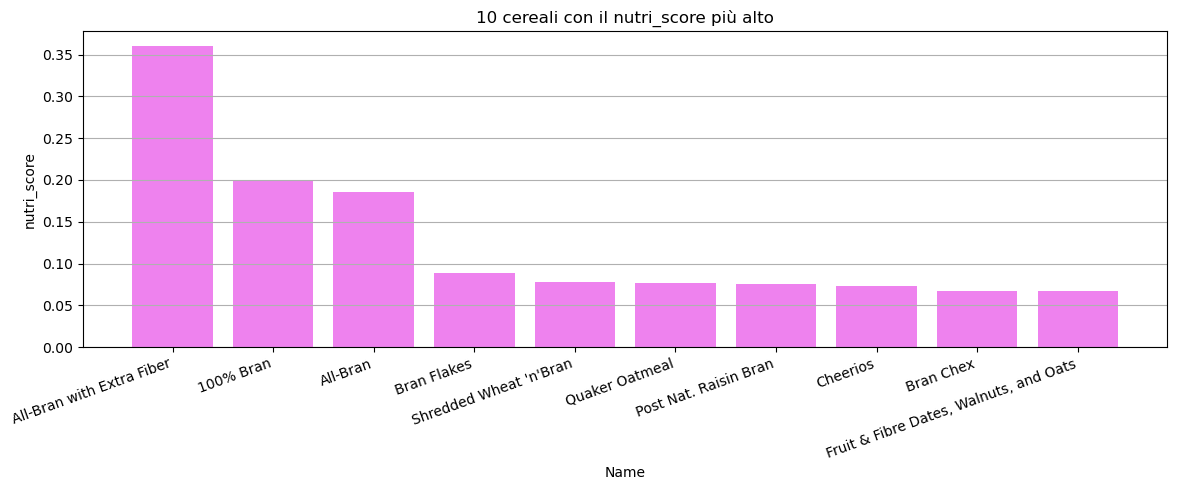

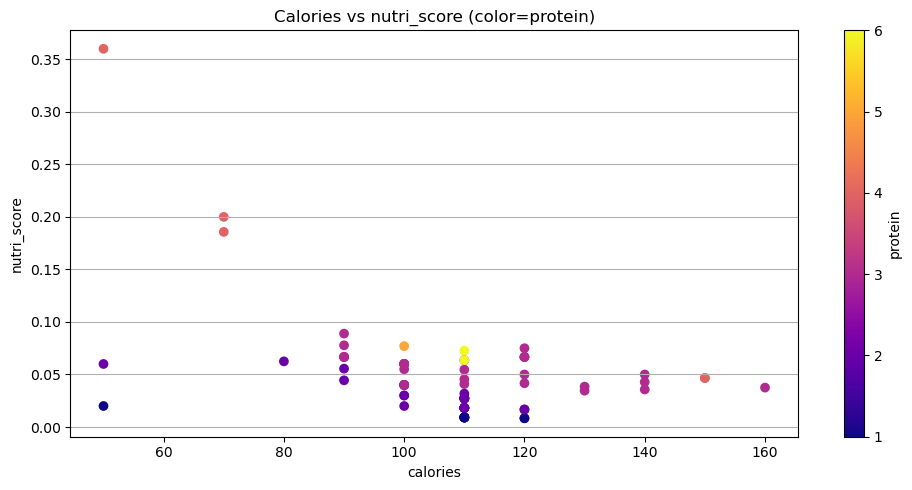

In [7]:
df = pd.read_csv('cereal.csv', sep=';')
# 1
df = df[df['calories']>0]
df['nutri_score'] = (df['protein'] + df['fiber'])/df['calories']
# 2
top5 = df.nlargest(5, 'nutri_score')
print(f"Top 5:\n{top5[['name', 'nutri_score']]}") 
# 3
df_filtered = df[(df['calories']<120) & (df['fiber']>2)]
# 4
top10 = df.nlargest(10, 'nutri_score')
plt.figure(figsize=(12,5))
plt.bar(top10['name'], top10['nutri_score'], color='violet')
plt.title('10 cereali con il nutri_score più alto')
plt.xlabel('Name')
plt.xticks(rotation=20, ha='right')
plt.ylabel('nutri_score')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
# 5
plt.figure(figsize=(10,5))
scatter = plt.scatter(df['calories'], df['nutri_score'], c=df['protein'], cmap='plasma')
plt.colorbar(scatter, label='protein')
plt.xlabel('calories')
plt.ylabel('nutri_score')
plt.title('Calories vs nutri_score (color=protein)')
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

## Esercizio 5 

Utilizza il dataset `imdb_top_1000.csv`, che contiene informazioni su 1000 film recensiti su IMDB.

1. Quanti **valori mancanti** ci sono per colonna? Elimina le righe con i valori mancanti.

2. Elimina la colonna `Overview`. Aggiungi una colonna (`main_genre`) con solo il primo genere della colonna `genre`. Quali sono i 5 generi più frequenti?

3. Che attore/attrice è stato/a più volte la `Star1` e quello/a che ha fatto più film.

4. Calcola l'IMDB_rating medio e il Gross medio di ogni genere. Fai uno scatter plot dell'IMDB_rating medio e il Gross medio di ogni genere. Riesci a mettere anche l'ettichetta del genere?

5. Visualizza la distribuzione del IMDB_rating  e la distribuzione del `Gross` dei primi 5 main_genre. (Hint fai due violin plot).




Valori mancanti per colonna: Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64
0                        Drama
1                 Crime, Drama
2         Action, Crime, Drama
3                 Crime, Drama
4                 Crime, Drama
5     Action, Adventure, Drama
6                 Crime, Drama
7    Biography, Drama, History
8    Action, Adventure, Sci-Fi
9                        Drama
Name: Genre, dtype: str
Cinque generi più frequenti: main_genre
Drama        192
Action       127
Comedy       104
Crime         74
Biography     73
Name: count, dtype: int64
Attor* più volte Star1 Tom Hanks; Direttore di più film Steven Spielberg
main_genre
Action       7.937008
Adventure    7.927586
Animation    7.926984
Biograph

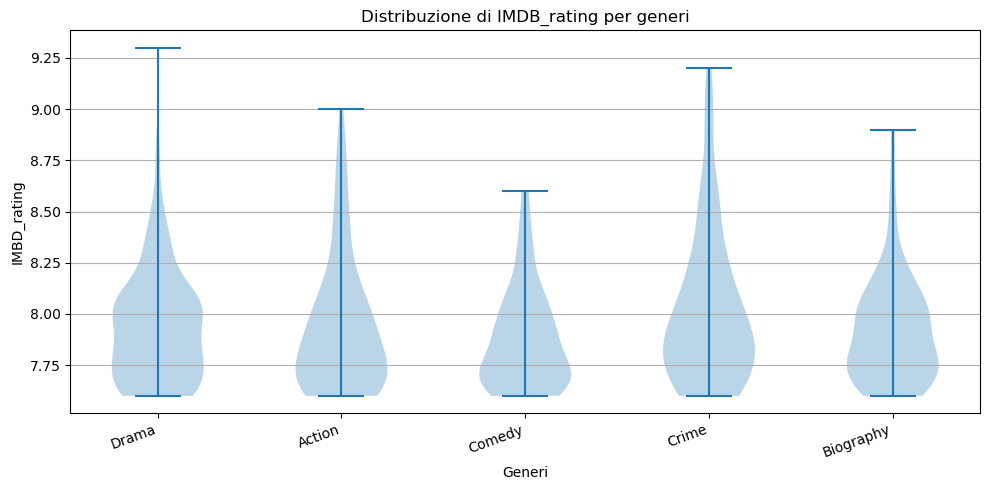

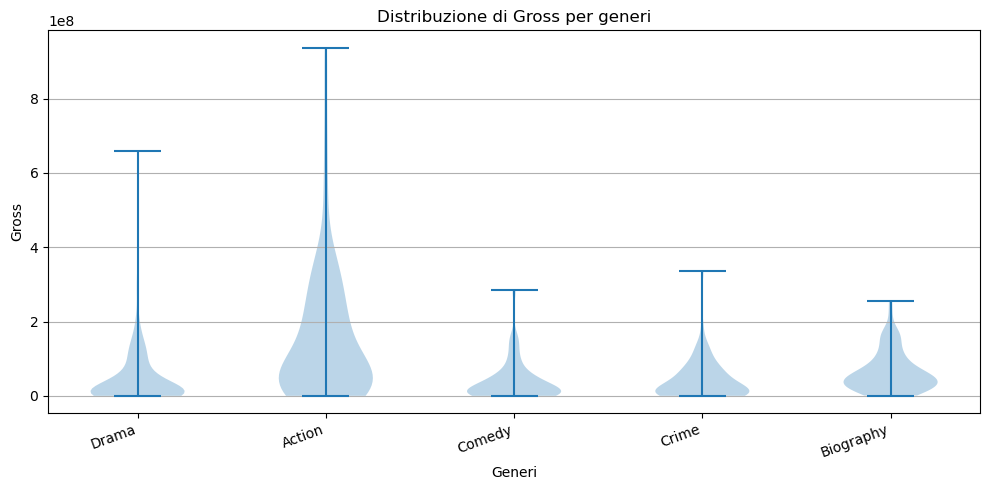

In [ ]:
df = pd.read_csv('imdb_top_1000.csv')
# 1
print(f"Valori mancanti per colonna: {df.isnull().sum()}")
df = df.dropna()
# 2
df = df.drop(columns=['Overview'])
print(df['Genre'].head(10))
df['main_genre'] = df['Genre'].str.split(',').str[0].str.strip()
print(f"Cinque generi più frequenti: {df['main_genre'].value_counts().head(5)}")
# 3
attore = df['Star1'].value_counts().idxmax()
direttore = df['Director'].value_counts().idxmax()
print(f"Attor* più volte Star1 {attore}; Direttore di più film {direttore}")
# 4
rating_medio = df.groupby('main_genre')['IMDB_Rating'].mean()
gross_medio = df.groupby('main_genre')['Gross'].mean()
print(rating_medio)
print(gross_medio)
# 5
generi = df['main_genre'].value_counts().head(5).index
data1 = [df[df['main_genre']==g]['IMDB_Rating'].values for g in generi]
data2 = [df[df['main_genre']==g]['Gross'].values for g in generi]

plt.figure(figsize=(10,5))
plt.violinplot(data1, positions=range(len(generi)))
plt.xticks(range(len(generi)), generi, rotation=20, ha='right')
plt.title('Distribuzione di IMDB_rating per generi')
plt.xlabel('Generi')
plt.ylabel('IMBD_rating')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.violinplot(data2, positions=range(len(generi)))
plt.xticks(range(len(generi)), generi, rotation=20, ha='right')
plt.title('Distribuzione di Gross per generi')
plt.xlabel('Generi')
plt.ylabel('Gross')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [16]:
# 3
attore = df['Star1'].value_counts().idxmax()
direttore = df['Director'].value_counts().idxmax()
print(f"Attor* più volte Star1 {attore}; Direttore di più film {direttore}")

Attor* più volte Star1 Tom Hanks; Direttore di più film Steven Spielberg


## Esercizio 6

Considera i seguenti dati, che :

`x = np.linspace(0, 10, 100)`  
`y = -3.5 * x + 2 + np.random.normal(0, 10, 100)`

Cerca di riprodurre la retta fittando i parametri della funzione y = ax + b.

1. Stima i parametri della retta.
2. Calcola l’intervallo di confidenza al 95% dei parametri a e b.
N.B il secondo output del metodo curve_fit è proprio la matrice di covarianza: `params, cov = curve_fit(retta, x, y)`. 
L'**errore standard** di ciascun parametro si calcola come:

$$
\text{errore\_standard}_i = \sqrt{\text{cov}(i, i)}
$$

dove $\text{cov}(i, i)$ è l'elemento diagonale $i$-esimo della **matrice di covarianza**.

L’**intervallo di confidenza al 95%** si approssima con:

$$
\text{parametro}_i \pm 1.96 \times \text{errore\_standard}_i
$$
3. Plotta i punti originali e la retta ottenuta con anche l'intervallo di confidenza

a = -3.739  IC 95%: [-4.419, -3.059]
b = 4.966  IC 95%: [1.029, 8.903]


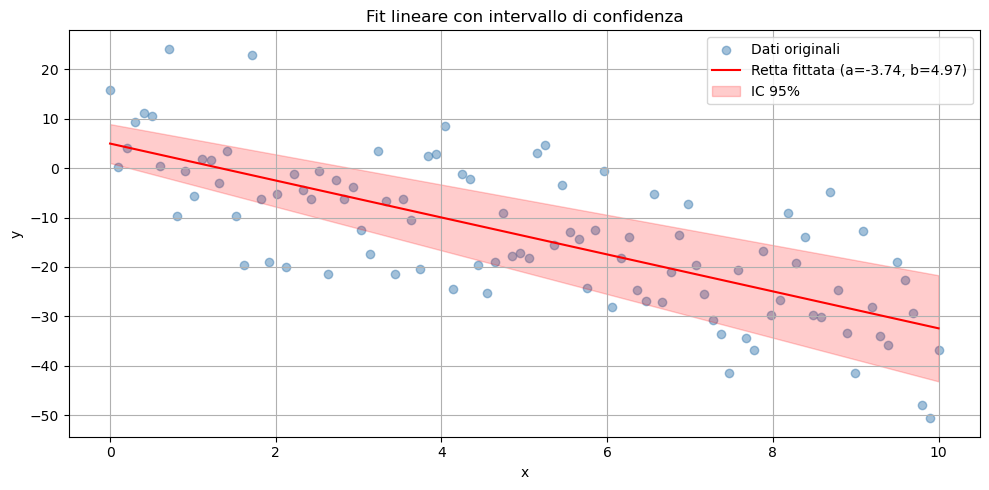

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.linspace(0, 10, 100)
y = -3.5 * x + 2 + np.random.normal(0, 10, 100)

# 1. Fit
def retta(x, a, b):
    return a * x + b

params, cov = curve_fit(retta, x, y)
a, b = params

# 2. Intervallo di confidenza al 95%
errori = np.sqrt(np.diag(cov))
a_min, a_max = a - 1.96 * errori[0], a + 1.96 * errori[0]
b_min, b_max = b - 1.96 * errori[1], b + 1.96 * errori[1]

print(f"a = {a:.3f}  IC 95%: [{a_min:.3f}, {a_max:.3f}]")
print(f"b = {b:.3f}  IC 95%: [{b_min:.3f}, {b_max:.3f}]")

# 3. Plot
y_fit = retta(x, a, b)
y_low = retta(x, a_min, b_min)
y_high = retta(x, a_max, b_max)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='steelblue', alpha=0.5, label='Dati originali')
plt.plot(x, y_fit, color='red', label=f'Retta fittata (a={a:.2f}, b={b:.2f})')
plt.fill_between(x, y_low, y_high, color='red', alpha=0.2, label='IC 95%')
plt.title('Fit lineare con intervallo di confidenza')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()